In [1]:
# Profile cleaned company and macro data, then save coverage and missingness reports.
# Describe missing data without imputation or feature selection.

In [2]:
import sys as _sys
from pathlib import Path as _Path
_UTILS_ROOT = next(path for path in (_Path.cwd().resolve(), *_Path.cwd().resolve().parents)
                   if (path / "notebook_utils.py").is_file())
if str(_UTILS_ROOT) not in _sys.path:
    _sys.path.insert(0, str(_UTILS_ROOT))
from notebook_utils import project_paths
from project_config import MAJOR_FINANCIAL_FIELDS, DISTRIBUTION_FIELDS, MACRO_FIELDS
from pathlib import Path
from html import escape
import base64
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, SymmetricalLogLocator

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "data/processed").is_dir() and (p / "notebooks").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Run inside the project.")
INPUT_DIR = project_paths(ROOT).processed
ARTIFACT_DIR = ROOT / "artifacts" / "04_profile_and_visualize_clean_data"
REPORT_DIR = ARTIFACT_DIR
FIGURE_DIR = ARTIFACT_DIR
YEARS = pd.Index(range(1993, 2027), name="year")
STATUSES = ["nonbankrupt", "bankrupt"]
STATUS_LABELS = {"nonbankrupt":"Non-bankrupt", "bankrupt":"Bankrupt"}
COLORS = {"nonbankrupt":"#2563a6", "bankrupt":"#d16b35"}
plt.rcParams.update({"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                     "figure.facecolor":"white","axes.titleweight":"bold","savefig.facecolor":"white"})
FIELD_LABELS = {"cash_short_term_investments":"Cash and short-term investments",
    "shareholders_equity":"Shareholders' equity","ebitda":"EBITDA","market_cap":"Market capitalization"}
def label(field): return FIELD_LABELS.get(field, field.replace("_", " ").capitalize())

company_long = pd.read_csv(INPUT_DIR/"clean_company_long.csv",dtype={
    "company_id":"category","field":"category","data_type":"category",
    "value":"float64","is_impossible":"boolean","value_issue":"string"})
macro_long = pd.read_csv(INPUT_DIR/"clean_macro_long.csv",dtype={"value":"float64","value_issue":"string"})
company_availability = pd.read_csv(INPUT_DIR/"company_availability.csv",dtype={
    "company_id":"string","company_type":"string","bloomberg_identifier":"string",
    "bloomberg_sector":"string","bloomberg_industry":"string"})
required = {
    "company":{"company_id","date","field","data_type","value","is_impossible","value_issue"},
    "macro":{"date","field","value","is_impossible","value_issue"},
    "availability":{"company_id","company_type","bloomberg_sector","bloomberg_industry",
        "bloomberg_identifier","bankruptcy_date","prediction_date","start_date","end_date",
        "first_financial_date","last_financial_date","first_market_date","last_market_date",
        "first_observed_date","last_observed_date","financial_history_years","market_history_months"}}
for name,frame in [("company",company_long),("macro",macro_long),("availability",company_availability)]:
    missing = required[name]-set(frame.columns)
    if missing: raise ValueError(f"Missing {name} columns: {sorted(missing)}")
    if frame.empty: raise ValueError(f"Empty {name} input.")
if company_availability["company_id"].isna().any() or company_availability["company_id"].duplicated().any():
    raise ValueError("Availability company IDs must be unique and nonmissing.")
invalid_date_counts = {}
for name,frame,columns in [
    ("company",company_long,["date"]),("macro",macro_long,["date"]),
    ("availability",company_availability,[c for c in company_availability if c.endswith("_date")])]:
    for column in columns:
        raw=frame[column]; parsed=pd.to_datetime(raw,errors="coerce",format="mixed")
        invalid_date_counts[f"{name}.{column}"]=int((raw.notna() & parsed.isna()).sum())
        frame[column]=parsed
metadata = company_availability.set_index("company_id")
for column in ["company_type","bloomberg_sector","bloomberg_industry"]:
    company_long[column]=company_long["company_id"].map(metadata[column]).astype("string").fillna("Unknown").astype("category")
company_long["year"]=company_long["date"].dt.year.astype("Int64")
company_long["missing"]=company_long["value"].isna()
company_long["value_issue"]=company_long["value_issue"].fillna("").astype("category")
FIELDS=sorted(company_long["field"].dropna().unique())


In [3]:
# Counts describe retained company/event IDs, not population bankruptcy rates.
company_counts=company_availability.groupby("company_type",dropna=False).size().rename("companies").reset_index()
def classification_counts(column):
    table=company_availability.groupby([column,"company_type"],dropna=False).size().unstack(fill_value=0).reindex(columns=STATUSES,fill_value=0)
    table["total"]=table.sum(axis=1)
    return table.sort_values("total",ascending=False).reset_index()
sector_counts=classification_counts("bloomberg_sector")
industry_counts=classification_counts("bloomberg_industry")
valid=company_long.loc[company_long["value"].notna() & np.isfinite(company_long["value"]) & company_long["date"].notna()]
coverage_parts=[]
for measure,mask in [("any_field",pd.Series(True,index=valid.index)),
    ("financial_assets",valid["field"].eq("total_assets")),("market_price",valid["field"].eq("adjusted_price"))]:
    counts=valid.loc[mask].groupby(["year","company_type"],observed=True)["company_id"].nunique()
    index=pd.MultiIndex.from_product([YEARS,STATUSES],names=["year","company_type"])
    counts=counts.reindex(index,fill_value=0).rename("companies").reset_index()
    counts.insert(0,"coverage_measure",measure); coverage_parts.append(counts)
coverage_by_year=pd.concat(coverage_parts,ignore_index=True)
filings=company_availability.loc[company_availability["company_type"].eq("bankrupt"),"bankruptcy_date"]
filing_counts=filings.dt.year.value_counts().reindex(YEARS,fill_value=0).sort_index().rename_axis("year").rename("companies").reset_index()
date_columns=["first_financial_date","last_financial_date","first_market_date","last_market_date","first_observed_date","last_observed_date"]
date_summary=pd.DataFrame([{"company_type":status,"date_field":column,"companies":len(part),
    "missing":int(part[column].isna().sum()),"earliest":part[column].min(),"latest":part[column].max()}
    for status,part in company_availability.groupby("company_type") for column in date_columns])
coverage_details=company_availability.copy()
financial_span=coverage_details["last_financial_date"].dt.year-coverage_details["first_financial_date"].dt.year+1
market_span=(coverage_details["last_market_date"].dt.year-coverage_details["first_market_date"].dt.year)*12+coverage_details["last_market_date"].dt.month-coverage_details["first_market_date"].dt.month+1
coverage_details["financial_span_years"]=financial_span
coverage_details["market_span_months"]=market_span
coverage_details["financial_internal_gap_years"]=financial_span-coverage_details["financial_history_years"]
coverage_details["market_internal_gap_months"]=market_span-coverage_details["market_history_months"]
coverage_details["years_before_first_assets"]=(coverage_details["first_financial_date"].dt.year-coverage_details["start_date"].dt.year).clip(lower=0)
coverage_details["months_before_first_price"]=((coverage_details["first_market_date"].dt.year-coverage_details["start_date"].dt.year)*12+coverage_details["first_market_date"].dt.month-coverage_details["start_date"].dt.month).clip(lower=0)
coverage_statistics=coverage_details.groupby("company_type")[["financial_history_years","market_history_months","financial_internal_gap_years","market_internal_gap_months"]].agg(["count","min","median","mean","max"]).reset_index()
coverage_statistics.columns=["_".join(str(p) for p in c if p) if isinstance(c,tuple) else c for c in coverage_statistics.columns]

shared_identifiers=company_availability.loc[company_availability["bloomberg_identifier"].duplicated(keep=False)].sort_values(["bloomberg_identifier","company_type"])
identifier_groups=company_availability.groupby("bloomberg_identifier")["company_type"].nunique()
cross_status_identifiers=identifier_groups.loc[identifier_groups.gt(1)].index
quality_rows=[]
def check(name,count,action):
    quality_rows.append({"check":name,"affected_records_or_ids":int(count),"status":"Review" if count else "Pass","interpretation_or_action":action})
check("Invalid date cells",sum(invalid_date_counts.values()),"Correct malformed dates in the relevant input.")
check("Missing company observation dates",company_long["date"].isna().sum(),"Undated values cannot enter year-based coverage.")
check("Missing macro observation dates",macro_long["date"].isna().sum(),"Correct macro observation dates.")
check("Duplicate company/date/field keys",company_long.duplicated(["company_id","date","field"]).sum(),"Resolve source duplicates before matching.")
check("Duplicate macro/date/field keys",macro_long.duplicated(["date","field"]).sum(),"Resolve duplicate macro records.")
check("Company IDs without metadata",company_long.loc[~company_long["company_id"].isin(metadata.index),"company_id"].nunique(),"Correct identifier joins.")
check("Invalid company types",(~company_availability["company_type"].isin(STATUSES)).sum(),"Confirm cohort membership.")
check("Invalid standardized IDs",(~company_availability["company_id"].str.fullmatch(r"(?:SA|NB)_\d+",na=False)).sum(),"Use standardized SA_/NB_ identifiers.")
check("Missing Bloomberg classifications",company_availability[["bloomberg_sector","bloomberg_industry"]].isna().any(axis=1).sum(),"Review the cleaning classification rule.")
check("Same Bloomberg identifier in both statuses",len(cross_status_identifiers),"Review issuer identity, filing history, and security reuse before matching controls.")
check("Bankrupt firms without filing dates",filings.isna().sum(),"Cannot assign these retained events to a filing year.")
check("Nonfinite nonmissing company values",(company_long["value"].notna() & ~np.isfinite(company_long["value"])).sum(),"Repair mechanical numeric cleaning.")
check("Nonfinite nonmissing macro values",(macro_long["value"].notna() & ~np.isfinite(macro_long["value"])).sum(),"Repair mechanical macro cleaning.")
check("Flagged impossible company values",company_long["is_impossible"].fillna(False).sum(),"Inspect source cells; clean values remain missing.")
check("Flagged impossible macro values",macro_long["is_impossible"].fillna(False).sum(),"Inspect source macro cells.")
check("Impossible values left numeric",(company_long["is_impossible"].fillna(False) & company_long["value"].notna()).sum(),"Correct cleaning if an impossible value is still numeric.")
cutoff=company_long["company_id"].map(metadata["prediction_date"])
start=company_long["company_id"].map(metadata["start_date"])
end=company_long["company_id"].map(metadata["end_date"])
check("On/after known prediction dates",(cutoff.notna() & company_long["date"].ge(cutoff)).sum(),"Correct temporal filtering. Non-bankrupt pseudo-dates remain unassigned.")
check("Outside collection windows",(company_long["date"].lt(start) | company_long["date"].gt(end)).sum(),"Correct collection-window filtering.")
check("Outside 1993-2026",(~company_long["year"].between(1993,2026)).fillna(False).sum(),"Review dates outside the requested display range.")
check("Financial-sector companies",company_availability["bloomberg_sector"].eq("Financials").sum(),"If the study remains limited to non-financial firms, resolve this scope before matching. No firms removed here.")

# Recompute all eight saved availability fields for consistency checks.
observed_ranges=valid.groupby("company_id",observed=True)["date"].agg(first_observed_date="min",last_observed_date="max")
asset_rows=valid.loc[valid["field"].eq("total_assets")]
price_rows=valid.loc[valid["field"].eq("adjusted_price")]
asset_ranges=asset_rows.groupby("company_id",observed=True)["date"].agg(first_financial_date="min",last_financial_date="max")
price_ranges=price_rows.groupby("company_id",observed=True)["date"].agg(first_market_date="min",last_market_date="max")
asset_years=asset_rows.groupby("company_id",observed=True)["year"].nunique().rename("financial_history_years")
price_months=price_rows.assign(month=price_rows["date"].dt.to_period("M")).groupby("company_id",observed=True)["month"].nunique().rename("market_history_months")
recomputed=observed_ranges.join([asset_ranges,price_ranges,asset_years,price_months]).reindex(metadata.index)
# Zeros below are summary counts of observed periods, not imputed raw values.
recomputed[["financial_history_years","market_history_months"]]=recomputed[["financial_history_years","market_history_months"]].fillna(0)
availability_differences=[]
for column in recomputed:
    same=recomputed[column].eq(metadata[column]) | (recomputed[column].isna() & metadata[column].isna())
    for company_id in metadata.index[~same]:
        availability_differences.append({"company_id":company_id,"field":column,"saved":metadata.at[company_id,column],"recomputed":recomputed.at[company_id,column]})
availability_differences=pd.DataFrame(availability_differences,columns=["company_id","field","saved","recomputed"])
check("Availability mismatches",len(availability_differences),"Correct summaries before using them to match histories.")
quality_checks=pd.DataFrame(quality_rows)
issue_counts=company_long.loc[company_long["value_issue"].ne("")].groupby(["field","value_issue"],observed=True).size().rename("records").reset_index()


In [4]:
# Missingness uses numeric values in dated records, not identifier/date columns.
def missingness_summary(keys):
    result=company_long.groupby(keys,observed=True,dropna=False).agg(
        records=("value","size"),missing_records=("missing","sum"),
        usable_records=("value","count"),companies=("company_id","nunique")).reset_index()
    result["missing_pct"]=100*result["missing_records"]/result["records"]
    return result
missing_by_field=missingness_summary(["field"]).sort_values("missing_pct",ascending=False)
missing_by_company=missingness_summary(["company_id"]).merge(
    company_availability[["company_id","company_type","bloomberg_sector","bloomberg_industry"]],
    on="company_id",how="left",validate="one_to_one").sort_values("missing_pct",ascending=False)
missing_by_year=missingness_summary(["year"])
missing_by_status=missingness_summary(["company_type"])
missing_by_sector=missingness_summary(["bloomberg_sector"]).sort_values("missing_pct",ascending=False)
missing_by_industry=missingness_summary(["bloomberg_industry"]).sort_values("missing_pct",ascending=False)
missing_field_status=missingness_summary(["field","company_type"])
missing_year_status=missingness_summary(["year","company_type"])
financial_year_field=company_long.loc[company_long["data_type"].eq("financial")].groupby(["year","field"],observed=True).agg(
    records=("value","size"),missing_records=("missing","sum")).reset_index()
financial_year_field["missing_pct"]=100*financial_year_field["missing_records"]/financial_year_field["records"]

# Count company/field pairs with no dated records separately. This does not create
# synthetic raw observations, including for unavailable pre-IPO periods.
company_field_counts=company_long.groupby(["company_id","field"],observed=True).agg(
    dated_records=("value","size"),usable_records=("value","count"))
company_field_index=pd.MultiIndex.from_product([metadata.index,FIELDS],names=["company_id","field"])
company_field_coverage=company_field_counts.reindex(company_field_index,fill_value=0).reset_index()
field_history_coverage=company_field_coverage.assign(
    no_dated_records=lambda d:d["dated_records"].eq(0),no_usable_values=lambda d:d["usable_records"].eq(0)
).groupby("field").agg(companies=("company_id","size"),
    companies_without_dated_records=("no_dated_records","sum"),
    companies_without_usable_values=("no_usable_values","sum")).reset_index()
field_history_coverage["no_usable_history_pct"]=100*field_history_coverage["companies_without_usable_values"]/field_history_coverage["companies"]
missing_by_field=missing_by_field.merge(field_history_coverage,on="field",suffixes=("","_roster"),validate="one_to_one")

# Assign cautious candidate causes using only evidence in the clean tables.
missing_examples=company_long.loc[company_long["missing"],["company_id","date","field","data_type",
    "value_issue","is_impossible","company_type","bloomberg_sector","bloomberg_industry"]].copy()
missing_examples["candidate_cause"]="undetermined"
missing_examples["confidence"]="requires_source_review"
first_field=valid.groupby(["company_id","field"],observed=True)["date"].min().rename("first_usable_field_date").reset_index()
missing_examples=missing_examples.merge(first_field,on=["company_id","field"],how="left",validate="many_to_one")
reported_before=missing_examples["first_usable_field_date"].lt(missing_examples["date"])
missing_examples.loc[reported_before,"candidate_cause"]="not_reported"
missing_examples.loc[reported_before,"confidence"]="candidate_prior_values_exist"
limitation_fields=set(missing_by_field.loc[
    missing_by_field["no_usable_history_pct"].ge(95) & missing_by_field["companies_roster"].ge(100),"field"])
limitation=missing_examples["field"].isin(limitation_fields)
missing_examples.loc[limitation,"candidate_cause"]="Bloomberg_field_limitation"
missing_examples.loc[limitation,"confidence"]="candidate_verify_field_definition"
first_price=missing_examples["company_id"].map(metadata["first_market_date"])
pre_price=missing_examples["data_type"].eq("market") & missing_examples["date"].lt(first_price)
missing_examples.loc[pre_price,"candidate_cause"]="pre_listing"
missing_examples.loc[pre_price,"confidence"]="candidate_first_price_proxy_only"
extraction=missing_examples["value_issue"].isin(["not_numeric","conflicting_duplicate"]) | missing_examples["is_impossible"].fillna(False)
missing_examples.loc[extraction,"candidate_cause"]="data_extraction_error"
missing_examples.loc[extraction,"confidence"]="observed_invalid_input_verify_source"
CAUSES=["pre_listing","not_reported","not_applicable","Bloomberg_field_limitation","data_extraction_error","undetermined"]
cause_counts=missing_examples.groupby("candidate_cause").size().reindex(CAUSES,fill_value=0).rename("missing_dated_records").rename_axis("candidate_cause").reset_index()
cause_confidence=missing_examples.groupby(["candidate_cause","confidence"]).size().rename("records").reset_index()
cause_rules=pd.DataFrame([
    ("pre_listing","Candidate only: dated market gaps before the first valid price, plus undated pre-price periods reported separately.","Verify IPO/listing date and predecessor/security changes."),
    ("not_reported","Candidate only when this company/field has an earlier usable value.","Check original statements and Bloomberg reporting history."),
    ("not_applicable","Never automatically assigned from these inputs.","Require an explicit applicability explanation; zero is not missing."),
    ("Bloomberg_field_limitation","Candidate if >=95% of retained firms lack usable field history (>=100 firms).","Verify FLDS definitions, supported securities, and history."),
    ("data_extraction_error","Nonnumeric, conflicting, or impossible input flags indicate source-review candidates.","Inspect original cells; impossible values may be vendor/source problems."),
    ("undetermined","Generic Bloomberg errors or gaps without sufficient evidence.","Original error subtypes are not in value_issue; inspect workbooks.")
],columns=["cause","decision_rule","evidence_required"])
review_examples=missing_examples.sort_values(["candidate_cause","company_id","date"]).groupby("candidate_cause",sort=True).head(20)


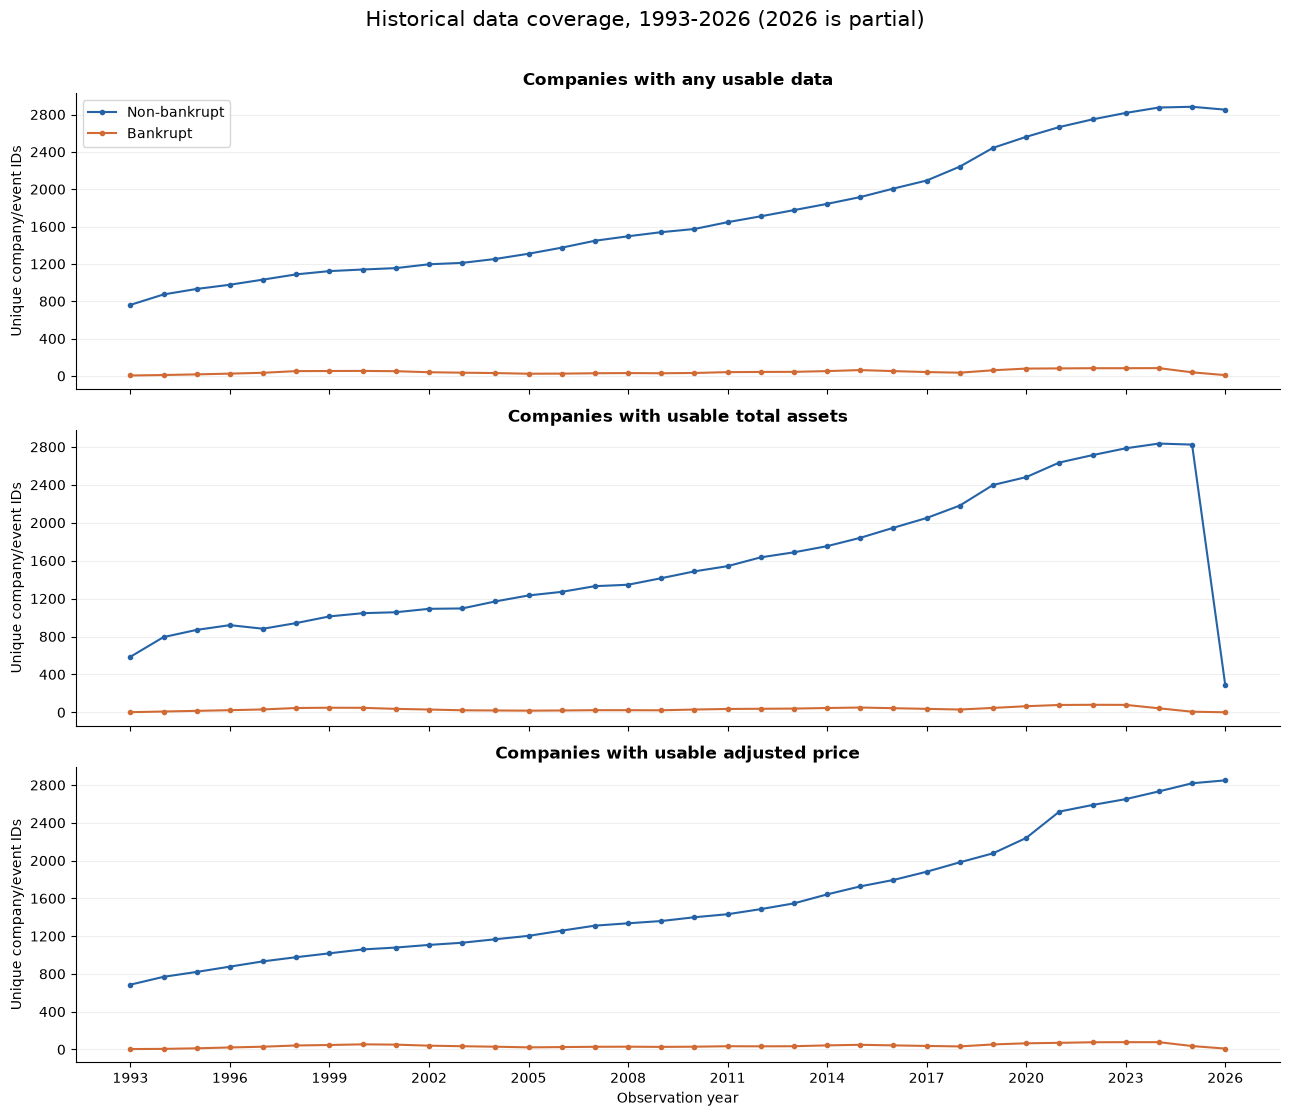

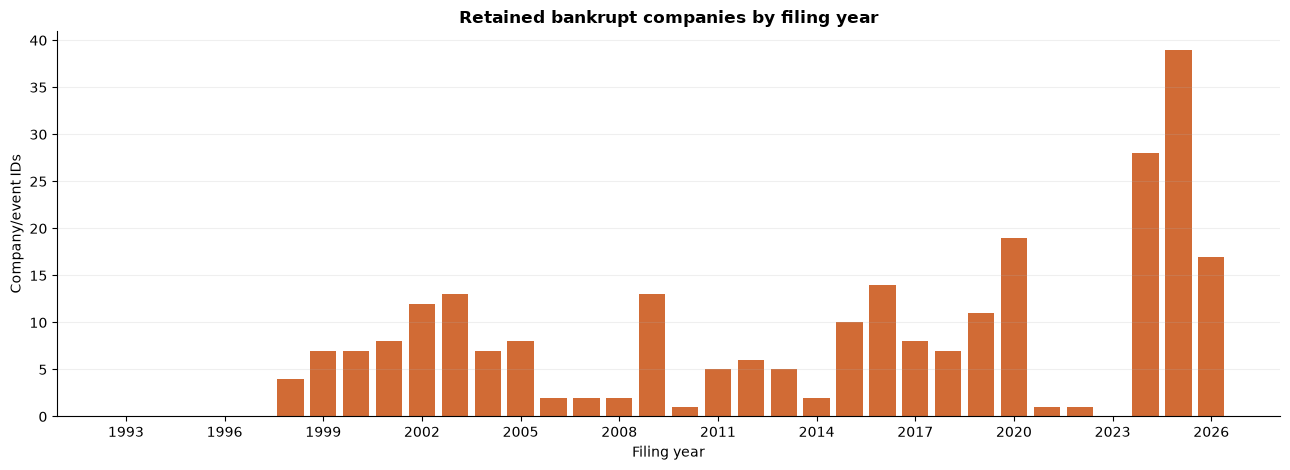

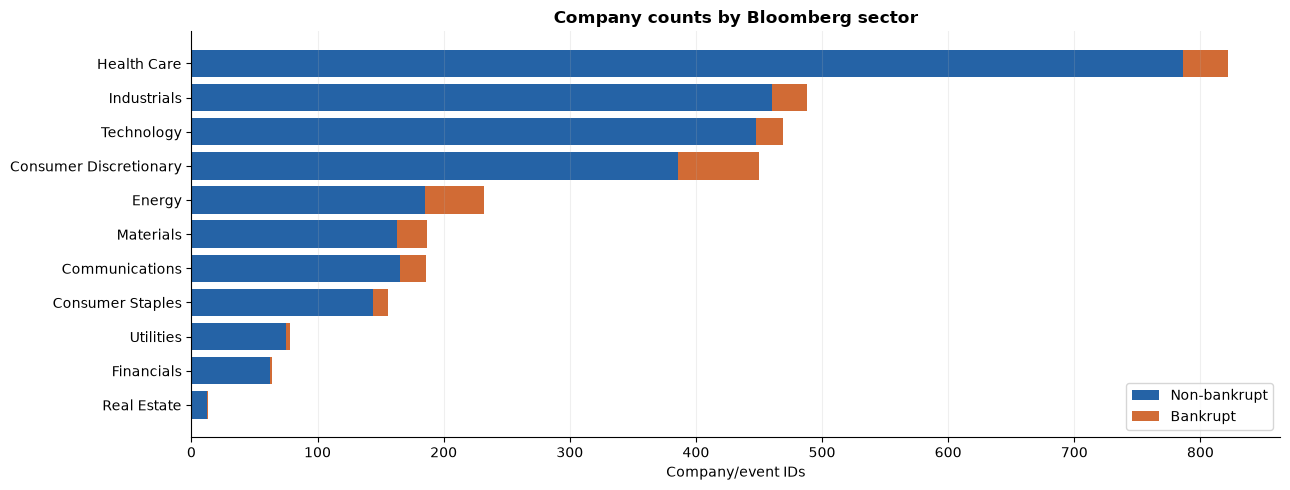

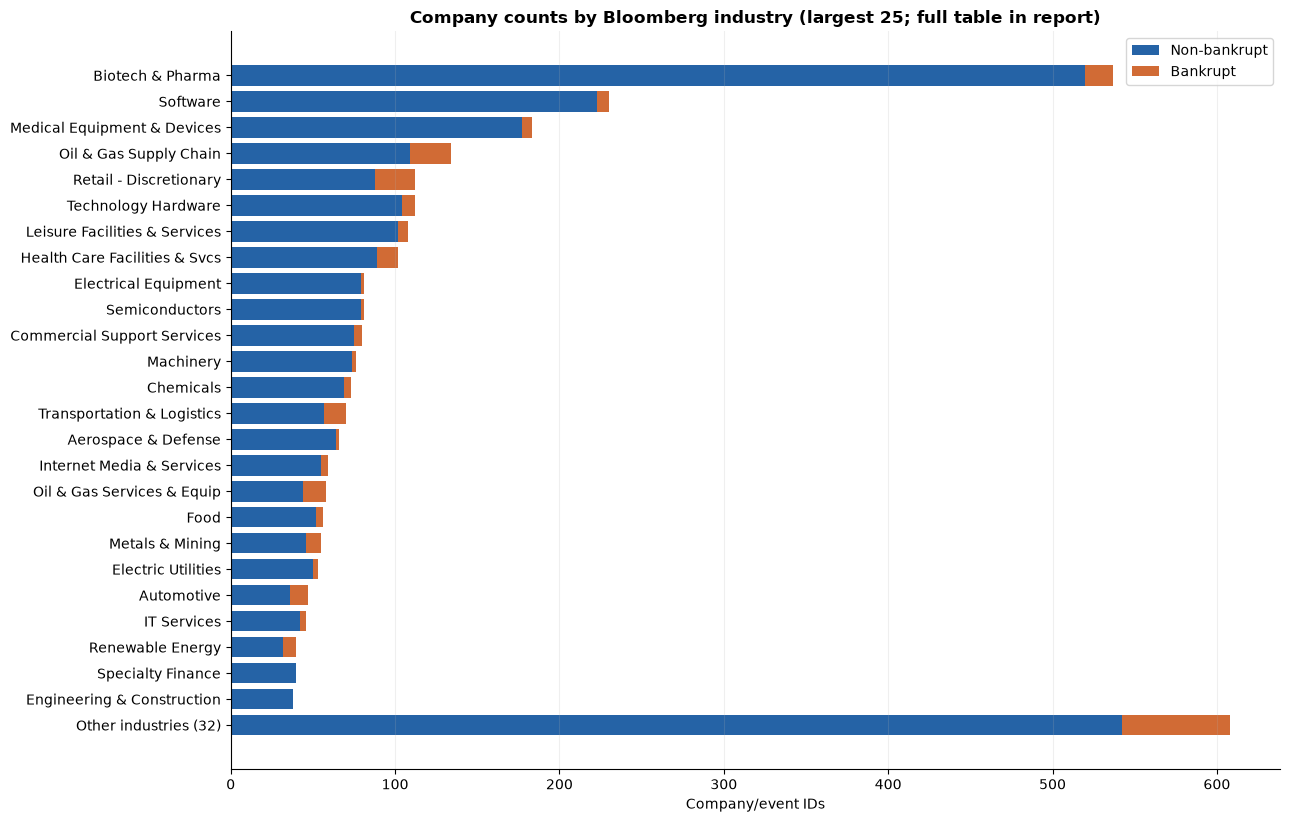

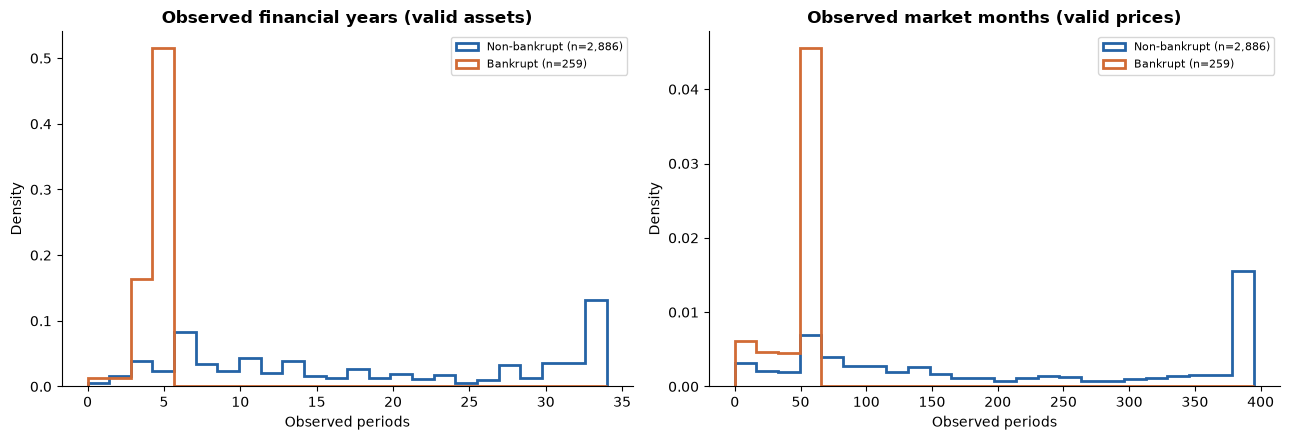

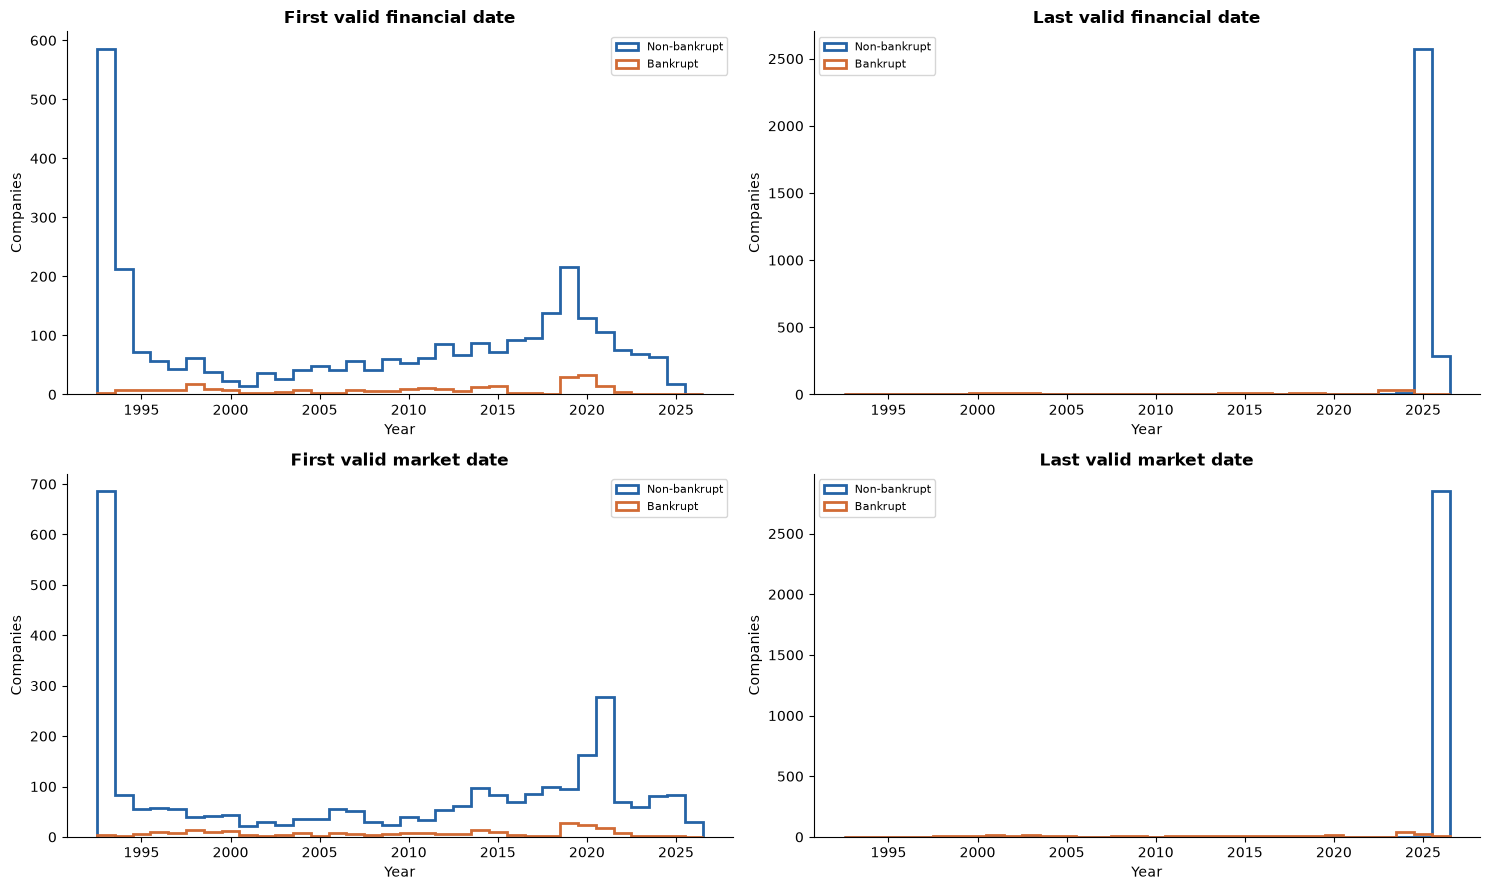

In [5]:
# Self-contained report images; save only the five requested standalone PNGs.
images={}
figure_paths=[]
def finish_figure(fig,key,filename=None):
    fig.tight_layout()
    buffer=io.BytesIO(); fig.savefig(buffer,format="png",dpi=180,bbox_inches="tight")
    images[key]=base64.b64encode(buffer.getvalue()).decode("ascii")
    if filename:
        FIGURE_DIR.mkdir(parents=True,exist_ok=True)
        path=FIGURE_DIR/filename; path.write_bytes(buffer.getvalue()); figure_paths.append(path)
    if plt.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)

fig,axes=plt.subplots(3,1,figsize=(13,11),sharex=True)
for ax,(measure,title) in zip(axes,[("any_field","Companies with any usable data"),
    ("financial_assets","Companies with usable total assets"),("market_price","Companies with usable adjusted price")]):
    data=coverage_by_year.loc[coverage_by_year["coverage_measure"].eq(measure)]
    for status in STATUSES:
        part=data.loc[data["company_type"].eq(status)]
        ax.plot(part["year"],part["companies"],marker="o",markersize=3,color=COLORS[status],label=STATUS_LABELS[status])
    ax.set_title(title); ax.set_ylabel("Unique company/event IDs"); ax.grid(axis="y",alpha=.2)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend(); axes[-1].set_xlabel("Observation year"); axes[-1].set_xticks(range(1993,2027,3))
fig.suptitle("Historical data coverage, 1993-2026 (2026 is partial)",fontsize=15,y=1.01)
finish_figure(fig,"data_coverage","data_coverage_by_year.png")
fig,ax=plt.subplots(figsize=(13,4.8))
ax.bar(filing_counts["year"],filing_counts["companies"],color=COLORS["bankrupt"])
ax.set(title="Retained bankrupt companies by filing year",xlabel="Filing year",ylabel="Company/event IDs")
ax.set_xticks(range(1993,2027,3)); ax.yaxis.set_major_locator(MaxNLocator(integer=True)); ax.grid(axis="y",alpha=.2)
finish_figure(fig,"filings","bankruptcies_by_year.png")

def plot_classification_counts(table,column,title,key,filename,top=None):
    chart=table.copy()
    if top is not None and len(chart)>top:
        other={column:f"Other industries ({len(chart)-top})",**{s:int(chart.iloc[top:][s].sum()) for s in STATUSES},"total":int(chart.iloc[top:]["total"].sum())}
        chart=pd.concat([chart.head(top),pd.DataFrame([other])],ignore_index=True)
    chart=chart.iloc[::-1]
    fig,ax=plt.subplots(figsize=(13,max(5,len(chart)*.32))); left=np.zeros(len(chart))
    for status in STATUSES:
        values=chart[status].to_numpy(); ax.barh(chart[column],values,left=left,label=STATUS_LABELS[status],color=COLORS[status]); left+=values
    ax.set(title=title,xlabel="Company/event IDs"); ax.legend(); ax.grid(axis="x",alpha=.2)
    finish_figure(fig,key,filename)
plot_classification_counts(sector_counts,"bloomberg_sector","Company counts by Bloomberg sector","sectors","sector_distribution.png")
plot_classification_counts(industry_counts,"bloomberg_industry","Company counts by Bloomberg industry (largest 25; full table in report)","industries","industry_distribution.png",top=25)
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for ax,column,title in zip(axes,["financial_history_years","market_history_months"],["Observed financial years (valid assets)","Observed market months (valid prices)"]):
    bins=np.linspace(0,max(1,company_availability[column].max()),25)
    for status in STATUSES:
        values=company_availability.loc[company_availability["company_type"].eq(status),column].dropna()
        ax.hist(values,bins=bins,density=True,histtype="step",linewidth=2,color=COLORS[status],label=f"{STATUS_LABELS[status]} (n={len(values):,})")
    ax.set(title=title,xlabel="Observed periods",ylabel="Density"); ax.legend(fontsize=8)
finish_figure(fig,"history_lengths")
fig,axes=plt.subplots(2,2,figsize=(15,9))
for ax,column,title in zip(axes.flat,date_columns[:4],["First valid financial date","Last valid financial date","First valid market date","Last valid market date"]):
    for status in STATUSES:
        years=company_availability.loc[company_availability["company_type"].eq(status),column].dt.year.dropna()
        ax.hist(years,bins=np.arange(1992.5,2027.5),histtype="step",linewidth=2,label=STATUS_LABELS[status],color=COLORS[status])
    ax.set(title=title,xlabel="Year",ylabel="Companies"); ax.legend(fontsize=8)
finish_figure(fig,"date_boundaries")


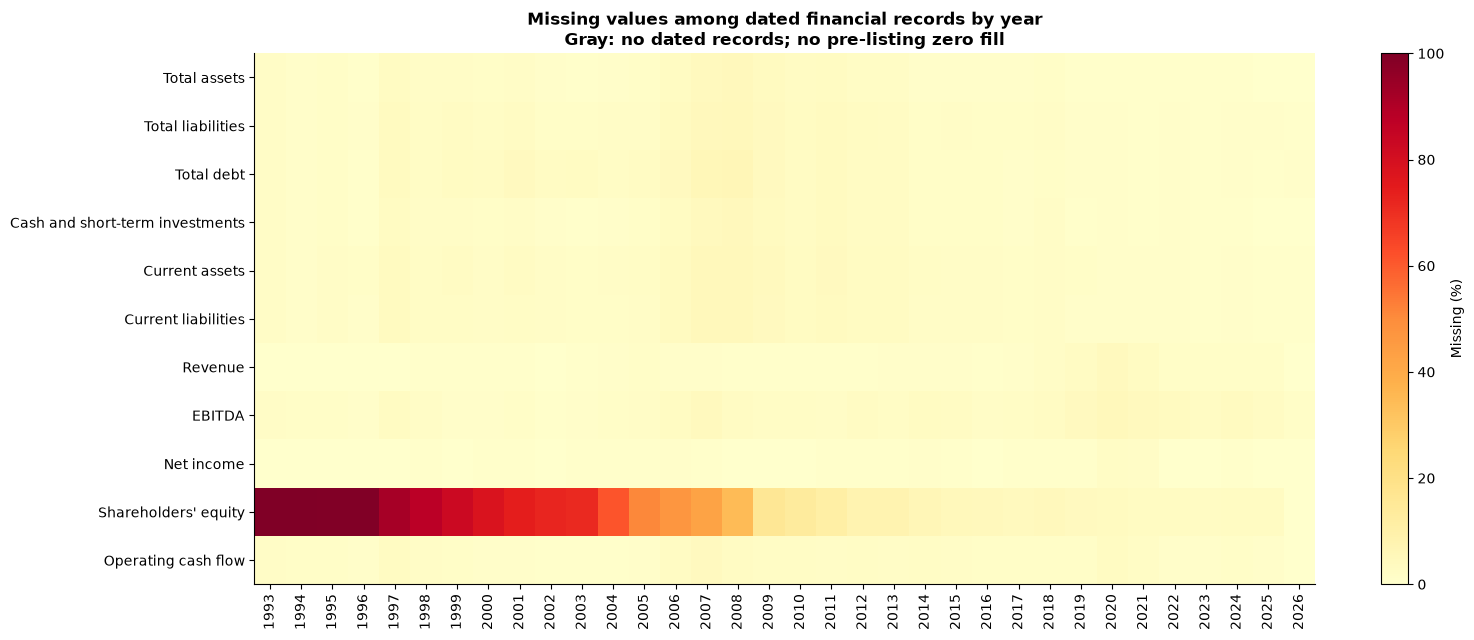

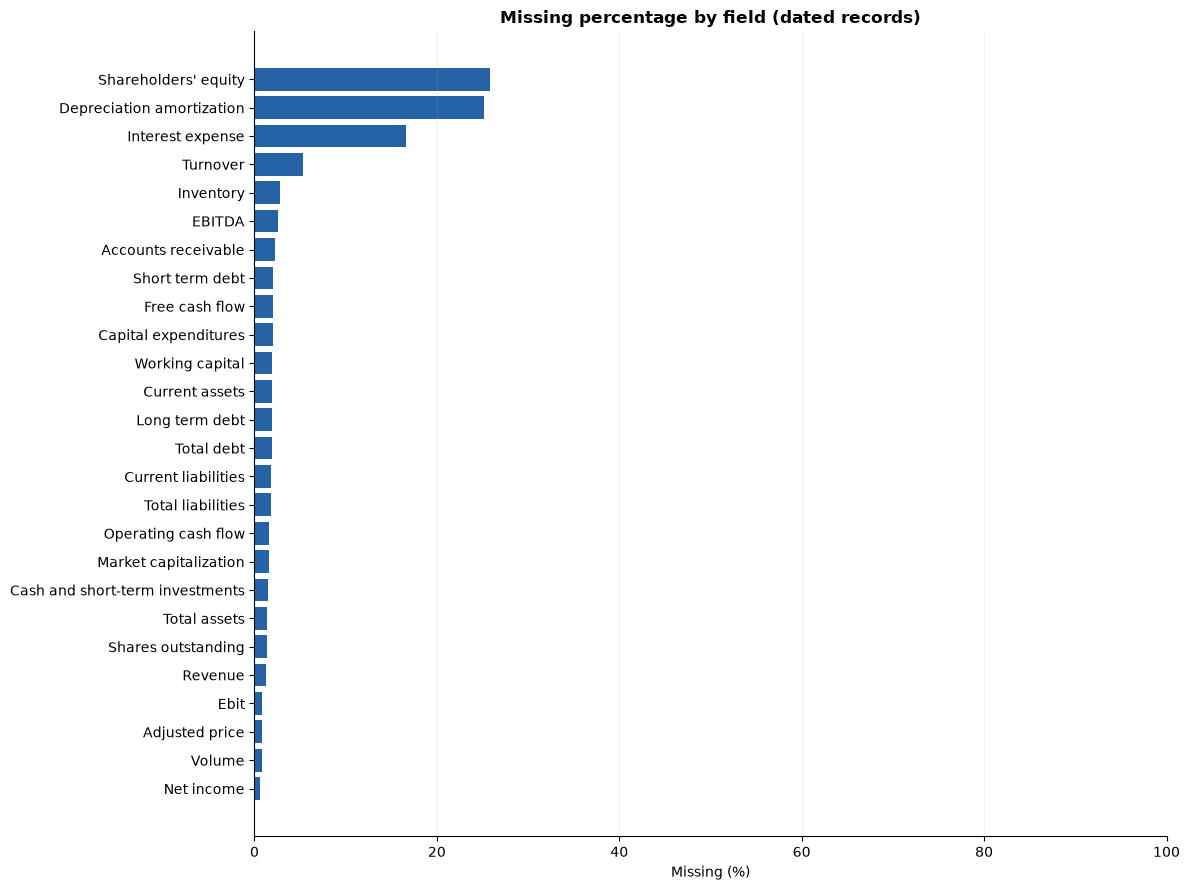

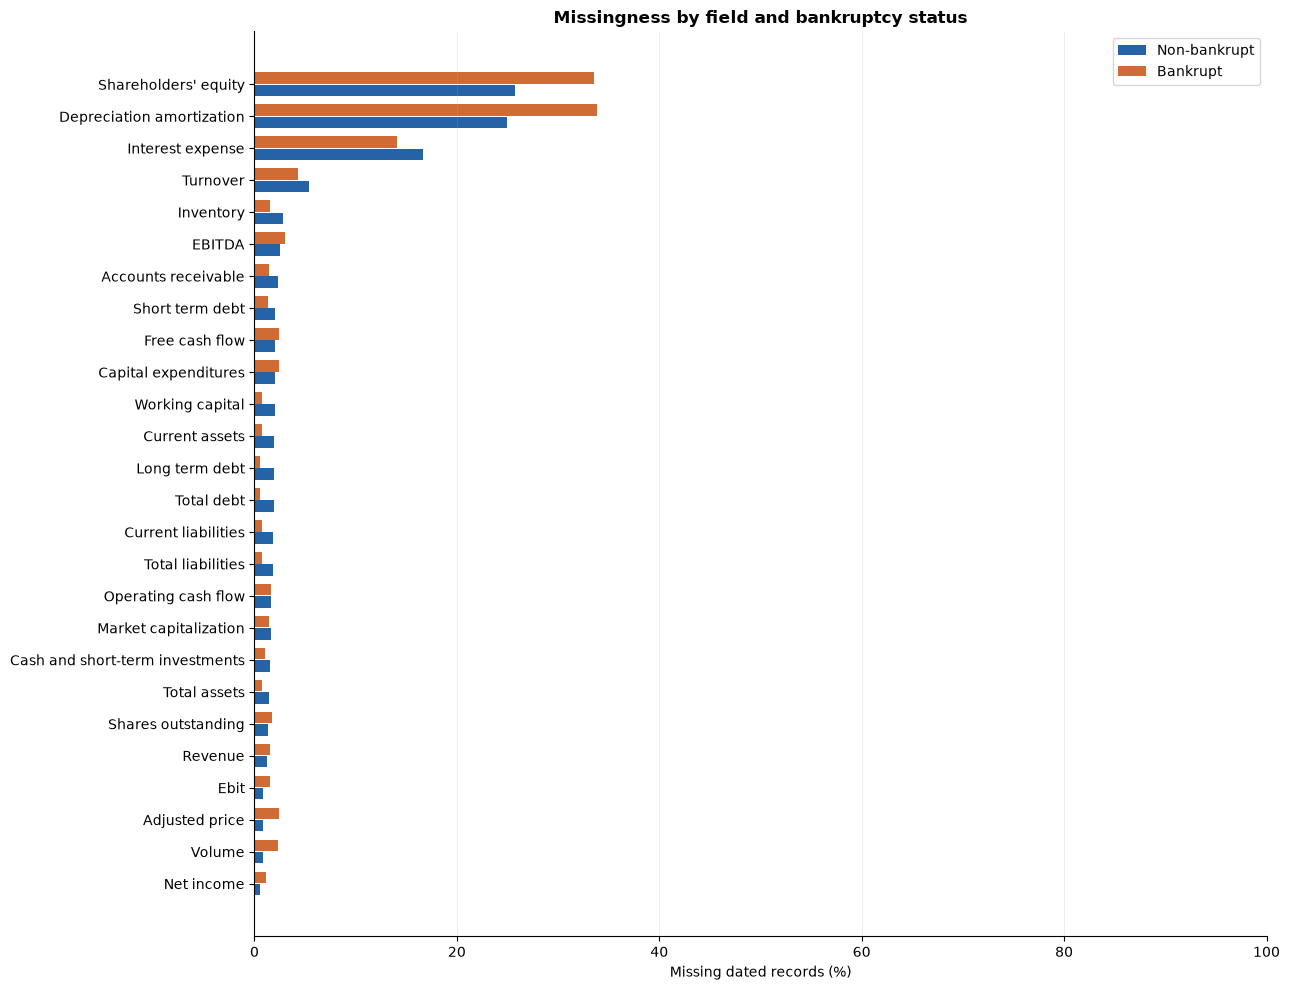

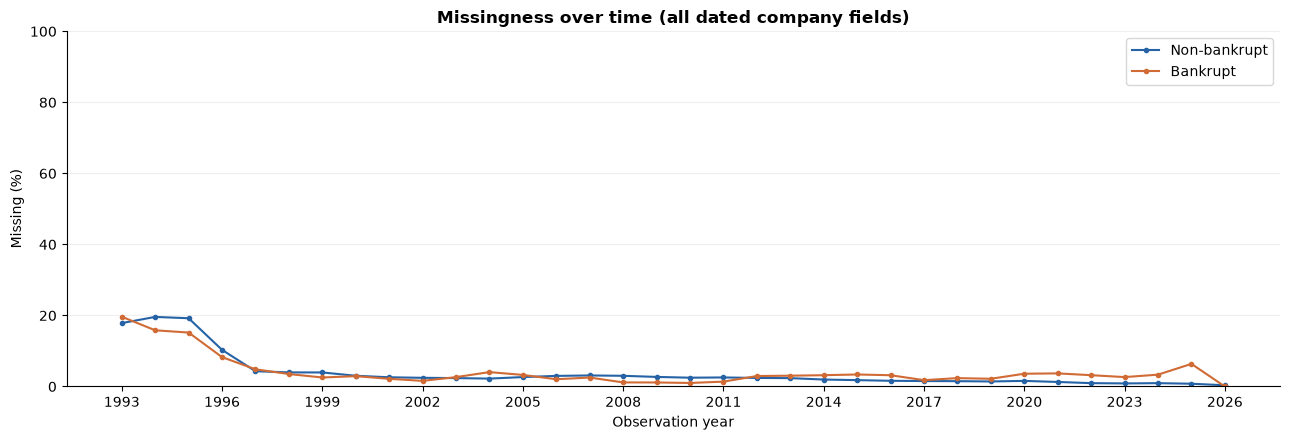

In [6]:
heatmap=financial_year_field.pivot(index="field",columns="year",values="missing_pct").reindex(
    index=[f for f in MAJOR_FINANCIAL_FIELDS if f in FIELDS],columns=YEARS)
fig,ax=plt.subplots(figsize=(16,6.5)); cmap=plt.get_cmap("YlOrRd").copy(); cmap.set_bad("#d1d5db")
im=ax.imshow(np.ma.masked_invalid(heatmap.to_numpy(dtype=float)),aspect="auto",vmin=0,vmax=100,cmap=cmap)
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS,rotation=90)
ax.set_yticks(range(len(heatmap))); ax.set_yticklabels([label(f) for f in heatmap.index])
ax.set_title("Missing values among dated financial records by year\nGray: no dated records; no pre-listing zero fill")
fig.colorbar(im,ax=ax,label="Missing (%)"); finish_figure(fig,"missing_heatmap","missingness_heatmap.png")
fig,ax=plt.subplots(figsize=(12,9)); ordered=missing_by_field.sort_values("missing_pct")
ax.barh([label(f) for f in ordered["field"]],ordered["missing_pct"],color="#2563a6")
ax.set(title="Missing percentage by field (dated records)",xlabel="Missing (%)",xlim=(0,100)); ax.grid(axis="x",alpha=.2)
finish_figure(fig,"missing_fields")
compare=missing_field_status.pivot(index="field",columns="company_type",values="missing_pct").reindex(index=ordered["field"],columns=STATUSES)
fig,ax=plt.subplots(figsize=(13,10)); positions=np.arange(len(compare))
for offset,status in zip([-.19,.19],STATUSES):
    ax.barh(positions+offset,compare[status],height=.36,color=COLORS[status],label=STATUS_LABELS[status])
ax.set_yticks(positions); ax.set_yticklabels([label(f) for f in compare.index]); ax.set_xlim(0,100)
ax.set(title="Missingness by field and bankruptcy status",xlabel="Missing dated records (%)"); ax.legend(); ax.grid(axis="x",alpha=.2)
finish_figure(fig,"missing_status")
fig,ax=plt.subplots(figsize=(13,4.5))
for status in STATUSES:
    part=missing_year_status.loc[missing_year_status["company_type"].eq(status)].set_index("year").reindex(YEARS)
    ax.plot(YEARS,part["missing_pct"],marker="o",markersize=3,color=COLORS[status],label=STATUS_LABELS[status])
ax.set(title="Missingness over time (all dated company fields)",xlabel="Observation year",ylabel="Missing (%)",ylim=(0,100))
ax.set_xticks(range(1993,2027,3)); ax.legend(); ax.grid(axis="y",alpha=.2)
finish_figure(fig,"missing_time")


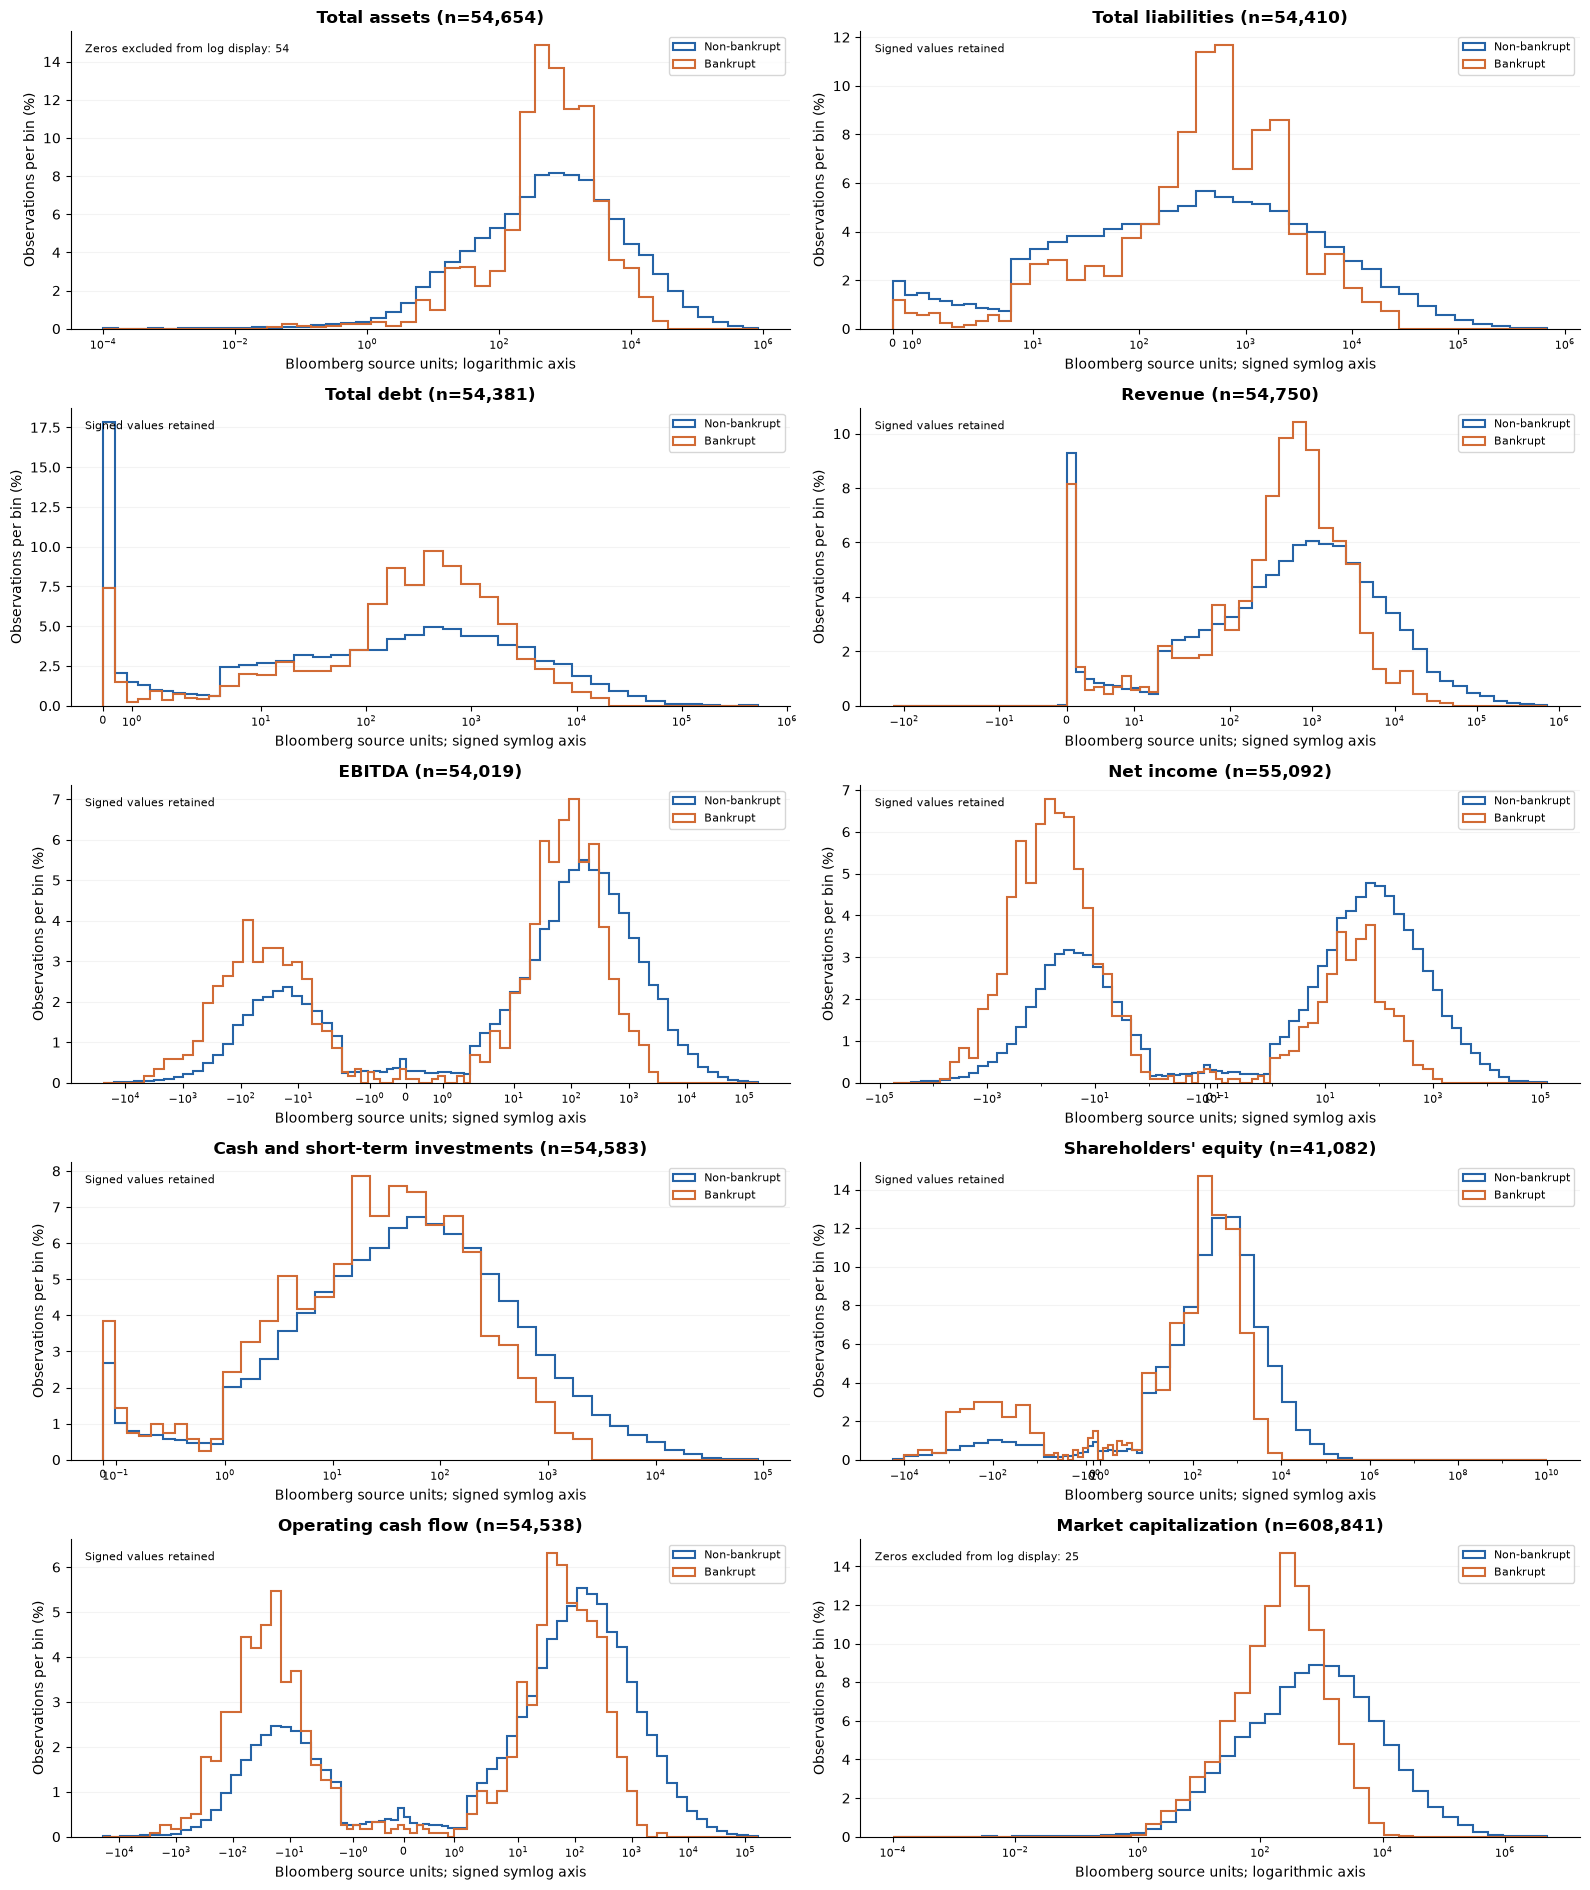

In [7]:
# Raw finite observations only. Preserve valid negative earnings, equity,
# and cash flow. Zeros excluded from a log axis are counted explicitly.
distribution_summary=[]
fig,axes=plt.subplots(5,2,figsize=(16,19))
for ax,field in zip(axes.flat,DISTRIBUTION_FIELDS):
    part=valid.loc[valid["field"].eq(field)]
    all_values=part["value"].to_numpy(dtype=float)
    if not len(all_values):
        ax.text(.5,.5,"No usable observations",ha="center",transform=ax.transAxes)
        ax.set_title(label(field)); continue
    abs_nonzero=np.abs(all_values[all_values!=0])
    use_log=field in {"total_assets","market_cap"}
    if use_log:
        positives=all_values[all_values>0]
        if len(positives):
            lo,hi=positives.min(),positives.max()
            bins=np.geomspace(lo,hi if hi>lo else lo*1.1,45)
            ax.set_xscale("log")
        else:
            bins=np.linspace(-1,1,20)
    else:
        threshold=max(float(np.median(abs_nonzero))*.02,1e-6) if len(abs_nonzero) else 1
        maximum=max(float(np.max(np.abs(all_values))),threshold*1.1)
        edges=np.geomspace(threshold,maximum,30)
        bins=np.unique(np.r_[-edges[::-1],np.linspace(-threshold,threshold,21),edges])
        lo,hi=float(all_values.min()),float(all_values.max())
        if hi==lo:
            lo,hi=lo-threshold,hi+threshold
        bins=np.unique(np.r_[lo,bins[(bins>lo) & (bins<hi)],hi])
        ax.set_xscale("symlog",linthresh=threshold)
        locator=SymmetricalLogLocator(base=10,linthresh=threshold)
        locator.set_params(numticks=8)
        ax.xaxis.set_major_locator(locator)
    for status in STATUSES:
        values=part.loc[part["company_type"].eq(status),"value"].to_numpy(dtype=float)
        if use_log: values=values[values>0]
        if len(values):
            # Percent per shared bin avoids confusing raw-unit densities on
            # logarithmic axes; each status has its own observation denominator.
            ax.hist(values,bins=bins,weights=np.full(len(values),100/len(values)),
                    histtype="step",linewidth=1.5,label=STATUS_LABELS[status],color=COLORS[status])
    ax.set_title(f"{label(field)} (n={len(part):,})")
    ax.set_xlabel("Bloomberg source units"+("; logarithmic axis" if use_log else "; signed symlog axis"))
    ax.set_ylabel("Observations per bin (%)"); ax.tick_params(axis="x",labelsize=8)
    ax.legend(fontsize=8); ax.grid(axis="y",alpha=.15)
    zero_note=f"Zeros excluded from log display: {int((all_values==0).sum()):,}" if use_log else "Signed values retained"
    ax.text(.02,.96,zero_note,transform=ax.transAxes,va="top",fontsize=8)
    for status in STATUSES:
        values=part.loc[part["company_type"].eq(status),"value"]
        distribution_summary.append({"field":field,"company_type":status,"observations":len(values),
            "negative":int(values.lt(0).sum()),"zero":int(values.eq(0).sum()),"min":values.min(),
            "p01":values.quantile(.01),"median":values.median(),"p99":values.quantile(.99),"max":values.max()})
finish_figure(fig,"financial_distributions")
distribution_summary=pd.DataFrame(distribution_summary)


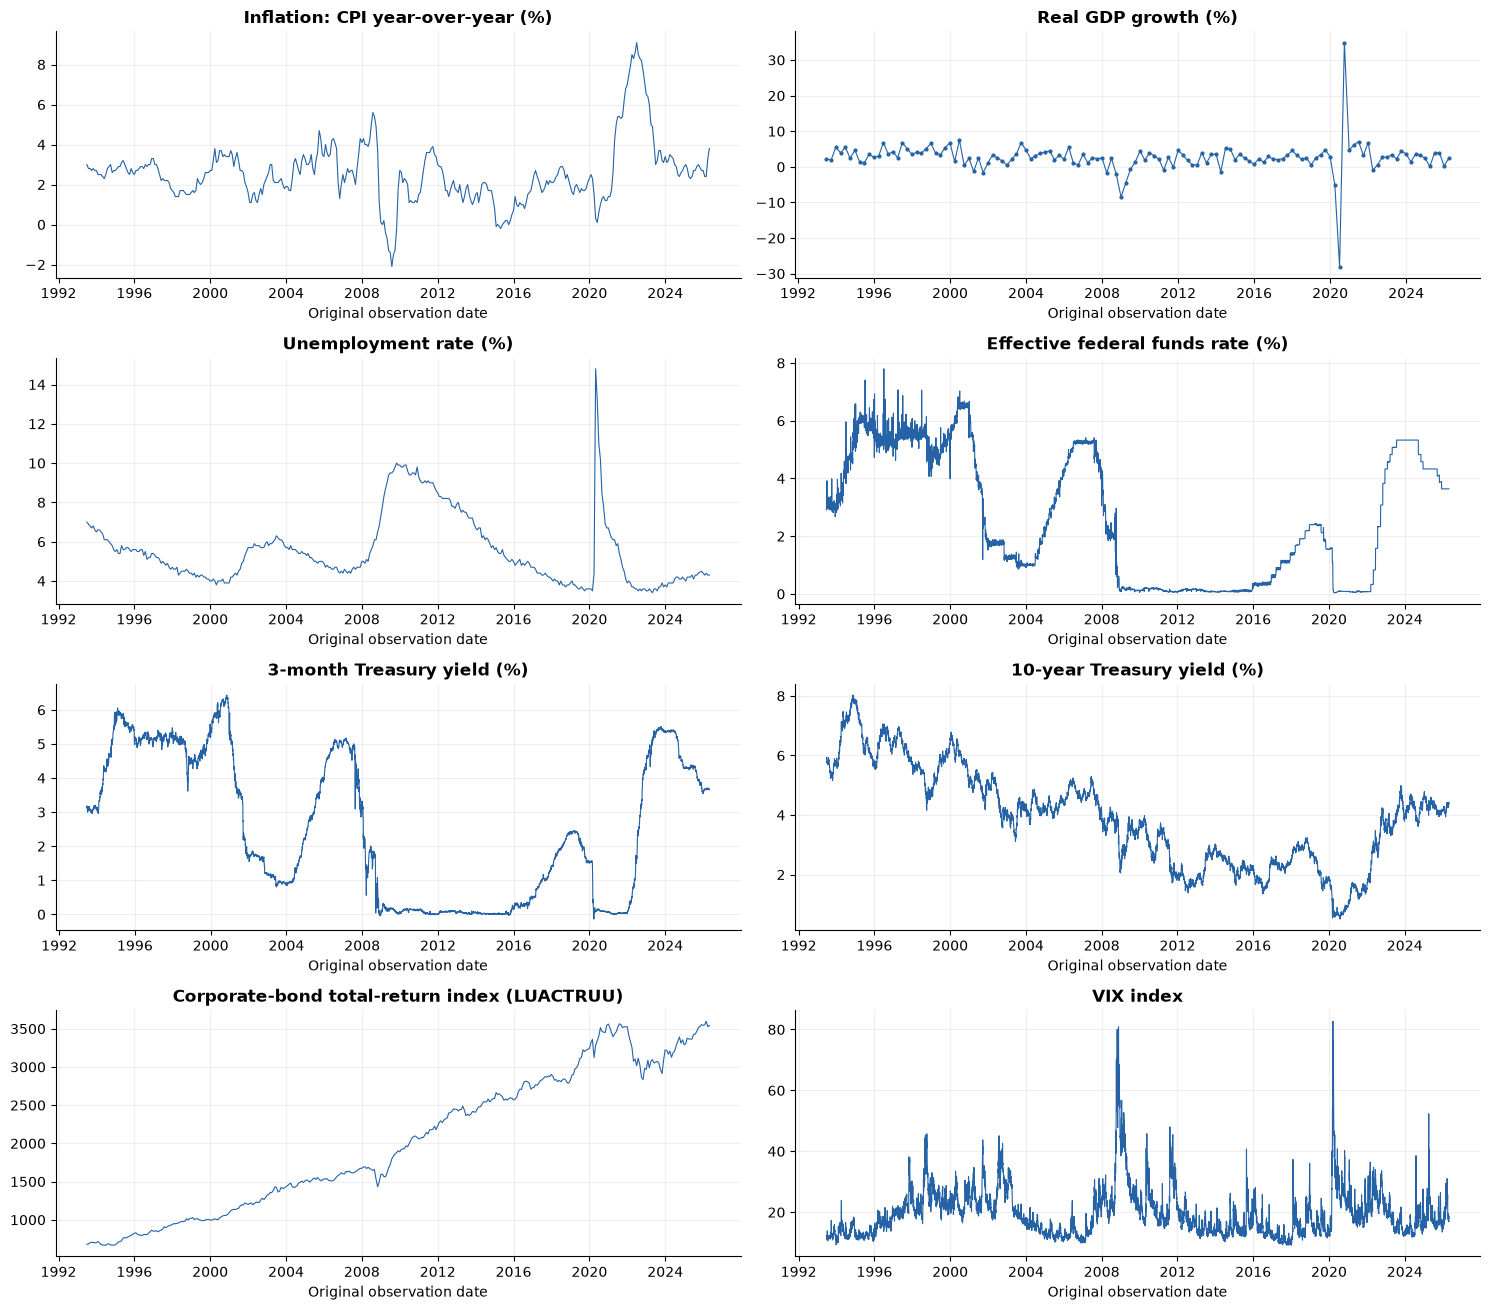

In [8]:
# Retain original macro dates/frequencies. No resampling, interpolation,
# forward fill, or assignment of later macro values to company observations.
macro_config = MACRO_FIELDS
macro_summary=[]
macro_year_rows=[]
for field,part in macro_long.groupby("field",sort=True):
    usable=part.loc[part["value"].notna()]
    config=macro_config.get(field,{})
    dates=usable["date"].sort_values().dropna().drop_duplicates()
    macro_summary.append({"field":field,"security":config.get("security","Unknown"),
        "bloomberg_field":config.get("field","Unknown"),"periodicity":config.get("periodicity","Unknown"),
        "records":len(part),"missing_records":int(part["value"].isna().sum()),
        "missing_pct":100*part["value"].isna().mean(),"first_usable_date":dates.min(),
        "last_usable_date":dates.max(),"largest_observation_gap_days":dates.diff().dt.days.max()})
    annual=part.assign(year=part["date"].dt.year).groupby("year").agg(
        records=("value","size"),usable_records=("value","count")).reindex(YEARS,fill_value=0).reset_index()
    annual.insert(0,"field",field); macro_year_rows.append(annual)
macro_summary=pd.DataFrame(macro_summary)
macro_year_coverage=pd.concat(macro_year_rows,ignore_index=True)
macro_alias_review=[]
if macro_config.get("credit_spread",{}).get("security")=="LUACTRUU Index":
    macro_alias_review.append({"stored_field":"credit_spread","source":"LUACTRUU Index / PX_LAST",
        "finding":"Corporate-bond total-return index level, not a credit yield spread",
        "action":"Use the accurate chart label. Correct the alias or collect a true spread before interpreting this as credit-spread data."})
macro_alias_review=pd.DataFrame(macro_alias_review,columns=["stored_field","source","finding","action"])
macro_titles={"inflation_cpi_yoy":"Inflation: CPI year-over-year (%)",
 "real_gdp_growth":"Real GDP growth (%)","unemployment_rate":"Unemployment rate (%)",
 "effective_federal_funds_rate":"Effective federal funds rate (%)",
 "treasury_3m_rate":"3-month Treasury yield (%)","treasury_10y_rate":"10-year Treasury yield (%)",
 "credit_spread":"Corporate-bond total-return index (LUACTRUU)","vix":"VIX index"}
macro_order=[f for f in macro_titles if f in set(macro_long["field"])]
macro_order+=sorted(set(macro_long["field"])-set(macro_order))
fig,axes=plt.subplots(int(np.ceil(len(macro_order)/2)),2,squeeze=False,
                      figsize=(15,3.3*int(np.ceil(len(macro_order)/2))))
for ax,field in zip(axes.flat,macro_order):
    part=macro_long.loc[macro_long["field"].eq(field)].sort_values("date")
    config=macro_config.get(field,{})
    title=macro_titles.get(field,label(field))
    if field=="credit_spread" and config.get("security")!="LUACTRUU Index":
        title=label(field)+" (verify units/source)"
    ax.plot(part["date"],part["value"],color="#2563a6",linewidth=.8,
            marker="o" if config.get("periodicity")=="Q" else None,markersize=2)
    ax.set_title(title); ax.set_xlabel("Original observation date"); ax.grid(alpha=.2)
for ax in axes.flat[len(macro_order):]: ax.set_visible(False)
finish_figure(fig,"macro_trends")


In [9]:
def table_html(frame,title,collapsed=False):
    table=frame.to_html(index=False,escape=True,na_rep="?",border=0,
                        float_format=lambda value:f"{value:,.2f}",classes="data-table")
    content=(f'<section><h2>{escape(title)}</h2><p class="table-count">{len(frame):,} rows</p>'
        '<input class="table-filter" aria-label="Filter table" placeholder="Filter this table">'
        f'<div class="table-wrap">{table}</div></section>')
    return f'<details><summary>{escape(title)} ({len(frame):,} rows)</summary>{content}</details>' if collapsed else content

def image_html(key,caption):
    return f'<figure><img src="data:image/png;base64,{images[key]}" alt="{escape(caption)}"><figcaption>{escape(caption)}</figcaption></figure>'

def paragraph(text): return f'<p>{escape(text)}</p>'

CSS=r"""
:root{color-scheme:light;--ink:#17263c;--muted:#526479;--line:#dde5ee}
*{box-sizing:border-box}body{margin:0;background:#eef3f8;color:var(--ink);font:16px/1.6 system-ui,sans-serif}
main{max-width:1320px;margin:32px auto;padding:36px;background:white;border-radius:12px;box-shadow:0 4px 24px #18334c12}
h1{font-size:30px;line-height:1.2;margin:0 0 12px}h2{font-size:21px;margin-top:28px}.intro{color:var(--muted)}
.cards{display:flex;flex-wrap:wrap;gap:16px;margin:22px 0}.card{flex:1;min-width:180px;padding:18px;background:#edf4fb;border-radius:8px}.card strong{display:block;font-size:27px}
figure{margin:24px 0}img{width:100%;height:auto}figcaption{color:var(--muted);font-size:14px;margin-top:8px}
.table-wrap{max-height:550px;overflow:auto;border:1px solid var(--line);border-radius:6px}.data-table{border-collapse:collapse;width:100%;font-size:13px}
th,td{padding:8px 10px;border-bottom:1px solid var(--line);text-align:left;vertical-align:top}th{position:sticky;top:0;background:#e8f0f8;z-index:1}
tbody tr:nth-child(even){background:#f6f9fc}.table-count{font-size:13px;color:var(--muted)}.table-filter{padding:8px 12px;margin-bottom:10px;border:1px solid #bccbdb;border-radius:5px;min-width:240px}
details{margin:20px 0;border:1px solid var(--line);border-radius:6px;padding:12px}summary{cursor:pointer;font-weight:600}.notice{padding:16px;background:#fff6df;border-left:4px solid #d69518;border-radius:4px}
nav a{margin-right:18px;color:#205797}footer{color:var(--muted);font-size:13px;border-top:1px solid var(--line);margin-top:30px;padding-top:16px}
@media(max-width:700px){main{margin:0;padding:18px;border-radius:0}h1{font-size:24px}}
"""
SCRIPT=r"""
document.querySelectorAll('.table-filter').forEach(input=>input.addEventListener('input',()=>{
 const term=input.value.toLowerCase();input.closest('section').querySelectorAll('tbody tr').forEach(row=>{
 row.hidden=!row.textContent.toLowerCase().includes(term);
 });
}));
"""

def write_report(filename,title,description,body):
    REPORT_DIR.mkdir(parents=True,exist_ok=True)
    document=(f'<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">'
        f'<title>{escape(title)}</title><style>{CSS}</style></head><body><main><nav>'
        '<a href="01_company_coverage.html">Company coverage</a><a href="02_missingness_report.html">Missingness</a><a href="03_macro_coverage.html">Macro coverage</a></nav>'
        f'<h1>{escape(title)}</h1><p class="intro">{escape(description)}</p>{body}'
        '<footer>Source: the three clean tables in data/processed. Source values and rows are preserved. No imputation, matching, or modeling.</footer>'
        f'</main><script>{SCRIPT}</script></body></html>')
    path=REPORT_DIR/filename; path.write_text(document,encoding="utf-8")
    return path

counts=company_availability["company_type"].value_counts()
cards='<div class="cards">'+''.join(f'<div class="card">{escape(title)}<strong>{value:,}</strong></div>' for title,value in [
    ("Retained companies",len(company_availability)),("Non-bankrupt",int(counts.get("nonbankrupt",0))),
    ("Bankrupt",int(counts.get("bankrupt",0))),("Bloomberg industries",len(industry_counts))])+'</div>'
coverage_body=cards+paragraph("Coverage is conditional on the cleaning exclusions for missing Bloomberg classifications and absent total assets. Counts are company/event IDs; the same security can appear under more than one ID. Each company can contribute to several observation years. These charts are not estimates of population bankruptcy rates.")
coverage_body+=image_html("data_coverage","Financial coverage uses usable total assets; market coverage uses usable adjusted price. Any-field coverage includes other valid values. 2026 has a partial collection window.")
coverage_body+=image_html("filings","Filing-year counts concern retained bankrupt records only. Non-bankrupt pseudo-dates remain unassigned.")
coverage_body+=table_html(company_counts,"Company counts")+table_html(coverage_by_year,"Company coverage by year and status",True)+table_html(filing_counts,"Bankruptcies by filing year",True)
coverage_body+=image_html("sectors","Current Bloomberg BICS classifications are not verified historical classifications.")
coverage_body+=image_html("industries","All industries appear in the full table; industries below the largest 25 are grouped in the chart.")
coverage_body+=table_html(sector_counts,"Company counts by Bloomberg sector",True)+table_html(industry_counts,"Company counts by Bloomberg industry",True)
coverage_body+=image_html("history_lengths","History lengths count observed years/months. Density distributions compare groups with different numbers of companies.")
coverage_body+=image_html("date_boundaries","Companies without valid market dates are excluded from date histograms and identified in the tables.")
coverage_body+=table_html(date_summary,"First and last financial/market dates by status")+table_html(coverage_statistics,"Historical coverage distribution statistics",True)
coverage_body+=table_html(coverage_details,"Company-specific dates, history lengths, and coverage gaps",True)
coverage_body+=image_html("financial_distributions","Raw financial observations by status. No winsorization or monetary unit conversion. Log plots show proportions among positive values, with omitted zeros counted explicitly; symlog plots retain signed values. Percentages use each status's observations and shared bins. Longer histories contribute more observations. Source units are preserved.")
coverage_body+=table_html(distribution_summary,"Raw financial distribution statistics",True)
coverage_body+='<div class="notice">Shared identifiers require issuer/event review before matching. Current classifications and recorded dates do not verify historical publication dates or unrevised data vintages.</div>'
coverage_body+=table_html(quality_checks,"Data quality checks requiring review")
coverage_body+=table_html(shared_identifiers,"Repeated Bloomberg identifiers across company IDs",True)+table_html(availability_differences,"Availability summary discrepancies",True)

missing_body=paragraph("Missing percentages are missing numeric values divided by explicitly dated field records, not metadata columns or all requested calendar dates. Absent rows do not enter that denominator. Tables separately identify firms with no dated or usable field history, missing internal periods, and pre-coverage periods. The two cohorts have different observation windows; these are descriptive comparisons before matching.")
missing_body+=image_html("missing_heatmap","Gray cells contain no dated records; they are not 0% missing.")
missing_body+=image_html("missing_fields","Record-level field missingness; whole-history coverage is in the accompanying table.")
missing_body+=image_html("missing_status","Each group uses its own dated-record denominator.")
missing_body+=image_html("missing_time","Record-weighted missingness over time reflects missing values and changes in the mix of companies and fields.")
missing_body+=table_html(missing_by_field,"Missingness by variable and whole-history absence")
for table,title in [(missing_by_status,"Missingness by bankruptcy status"),(missing_by_year,"Missingness by year"),
    (missing_by_sector,"Missingness by sector"),(missing_by_industry,"Missingness by industry"),
    (missing_by_company,"Missingness by company"),(missing_field_status,"Field missingness by bankruptcy status")]:
    missing_body+=table_html(table,title,True)
missing_body+=table_html(coverage_details[["company_id","company_type","first_financial_date","first_market_date","years_before_first_assets","months_before_first_price","financial_internal_gap_years","market_internal_gap_months"]],"Absent periods and pre-coverage proxies",True)
missing_body+='<div class="notice">Pre-price history is only a candidate for pre-listing: first price is not a verified IPO date. No not-applicable decisions are confirmed by these inputs. Generic Bloomberg errors cannot establish their cause because the original error subtype is absent from the clean tables. Structural absence counts are not zero-filled raw observations.</div>'
missing_body+=table_html(cause_rules,"Missing-value cause decision rules")+table_html(cause_counts,"Candidate causes among missing dated records")
missing_body+=table_html(cause_confidence,"Candidate causes and confidence",True)+table_html(review_examples,"Source-review examples (up to 20 per candidate cause)",True)
missing_body+=table_html(issue_counts,"Mechanical value issues by field",True)
missing_body+=paragraph("Review identifier overlap, failed temporal/availability checks, impossible or conflicting source cells, and fields lacking usable history. Verify each cause against original workbooks, listing records, and Bloomberg definitions before making missingness or eligibility decisions. No values are imputed here.")

macro_body=paragraph("Original macro dates and frequencies are preserved. Lines connect recorded values for visualization; there is no resampling, interpolation, forward fill, or assignment of macro values to companies. Different bankruptcy years reflect different macroeconomic conditions, which later event-time matching must address. Revisions and publication dates are not verified by these files.")
if not macro_alias_review.empty:
    macro_body+='<div class="notice">The stored credit_spread field is LUACTRUU / PX_LAST, a corporate-bond total-return index level. It is not a credit yield spread. A true credit-spread series has not been collected in this mapping. See <a href="https://assets.bbhub.io/professional/sites/27/US-Corporate-Index.pdf">Bloomberg US Corporate Index methodology</a>.</div>'
macro_body+=image_html("macro_trends","Inflation, GDP, unemployment, policy rate, Treasury yields, corporate-bond total-return index, and VIX at their original frequencies.")
macro_body+=table_html(macro_summary,"Macro dates, frequencies, missingness, and gaps")+table_html(macro_year_coverage,"Macro coverage by year",True)
macro_body+=table_html(macro_alias_review,"Macro label corrections requiring review")
macro_body+=table_html(macro_long.loc[macro_long["is_impossible"].fillna(False) | macro_long["value_issue"].notna()].head(100),"Macro value issues (first 100)",True)
report_paths=[
    write_report("01_company_coverage.html","Company coverage and financial distributions","Historical coverage of retained firms, 1993-2026.",coverage_body),
    write_report("02_missingness_report.html","Missingness and source-review decisions","Observed missingness, structural gaps, and cautious cause classification.",missing_body),
    write_report("03_macro_coverage.html","Macroeconomic coverage and trends","Historical macro context before event-time matching.",macro_body),
]
